In [1]:
import pickle
import os
from DataParsing import CGT
import matplotlib.pylab as plt

## Check Running Simulations

Keep running
Keep running
Keep running


Text(0, 0.5, 'Rg')

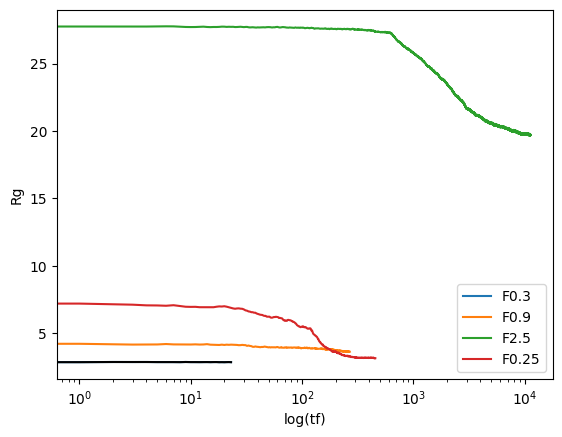

In [39]:
import numpy as np
from scipy.integrate import simpson
from scipy import stats

def RgParse(path):
    Nlpf = 101
    D = np.loadtxt(path)
    Nf = D.shape[0]//101
    D = D.reshape(Nf,Nlpf,2)
    
    #Get timeframe from first row
    t = D[:,0,0]/1e5
    #Get Rg from second column
    Rg = D[:,1:,1]
    return t,Rg

def findEquil(t, Rg):
        cutoff = 0.05

        #Compute autocorrelation
        dRg = Rg - Rg.mean()
        result = np.correlate(dRg, dRg, mode = 'full')
        result = result[result.size // 2:] # Keep the positive lags
        acf = result / result[0] #Normalized autocorrelation
        
        #Apply numerical integration
        positive_acf = acf[acf > 0]  # Ignore negative part to avoid integration errors
        tau_c = simpson(positive_acf, dx=1) #Correlation time
        t_scaled = t/tau_c
        
        for i in range(len(t)-int(tau_c)//2):
            res = stats.linregress(t_scaled[i:], Rg[i:])
            if res.pvalue >= cutoff:
                return i
        
        print('Keep running')
        return len(t)

path = [
    #Block 5
    '../block5/T0.1/force0.3/p9/sv.rc2.5N100T0.1p1',
    '../block5/T0.3/force0.9/p2/sv.rc2.5N100T0.3p1',
    #Block 10
    '../block10/T0.1/force2.5/p2/sv.rc2.5N100T0.1p1',
    '../block10/T0.3/force0.25/p2/sv.rc2.5N100T0.3p1',
    ]

f = [0.3, 0.9, 2.5, 0.25]

for i in range(len(path)):
    t, Rg = RgParse(path[i])
    t = t-t[0]
    Rg = Rg.mean(axis = 1)
    eqT = findEquil(t, Rg)
    plt.plot(t, Rg, label = f'F{f[i]}')
    plt.plot(t[eqT:], Rg[eqT:], color = 'black')

plt.legend()
plt.xscale('log')
plt.xlabel('log(tf)')
plt.ylabel('Rg')

## Block 1

No equilibrium detected. Use the last 40 timestep of the data
No equilibrium detected. Use the last 40 timestep of the data
No equilibrium detected. Use the last 40 timestep of the data
Slope is -0.0006693442687746745 pm 0.0002722064436473979 with p value 0.018034891660180904
No equilibrium detected. Use the last 40 timestep of the data
No equilibrium detected. Use the last 40 timestep of the data


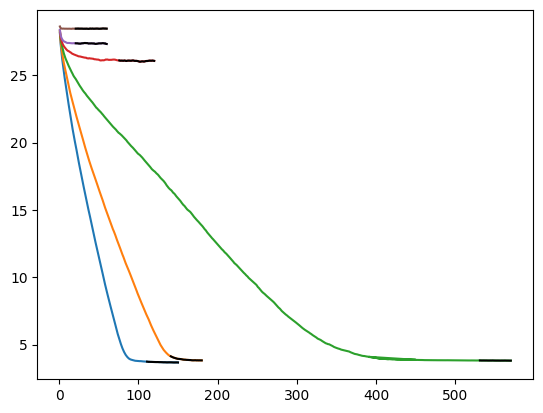

In [2]:
#T = 0.1
f = [0, 0.5, 1, 1.5, 2, 5]
t = 0.1
Rgfolder = '../Data/Block1/Radius of gyration/ForcesT01'
Reefolder = '../Data/Block1/End-to-end distance/ForcesT01'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT01 = CGT(f, t, 1, Reepaths, Rgpaths)

No equilibrium detected. Use the last 40 timestep of the data
Slope is -0.000401719145394008 pm 0.00015491545778154544 with p value 0.012440449507243748


KeyboardInterrupt: 

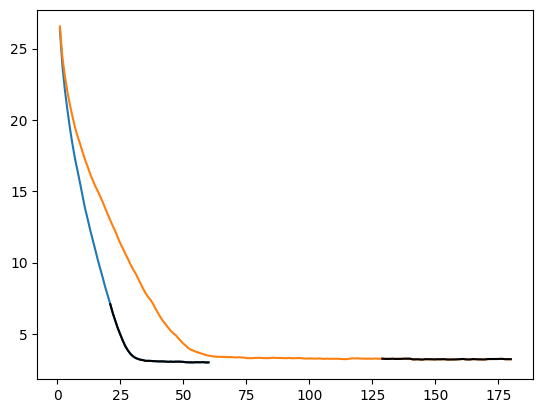

In [3]:
#T = 0.3
f = [0, 0.5, 1, 1.5, 2, 5]
t = 0.3
Rgfolder = '../Data/Block1/Radius of gyration/ForcesT03'
Reefolder = '../Data/Block1/End-to-end distance/ForcesT03'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT03 = CGT(f, t, 1, Reepaths, Rgpaths)

Slope is -0.0015272085784313637 pm 0.0007858402167885535 with p value 0.07097416871683189
Slope is -0.003206285648826979 pm 0.0016699836060041656 with p value 0.06441729501480627
Slope is -0.011510074125873954 pm 0.007861129787754172 with p value 0.1738613371083371
Slope is -0.0009336796294715196 pm 0.0004989408019221727 with p value 0.06715694106360885
Slope is 0.0004447691898577389 pm 0.00023562002116286313 with p value 0.06206162810368635
Slope is -0.0010028406593405178 pm 0.0006997075952965946 with p value 0.1641810479013487
Slope is -6.383742964356474e-05 pm 0.00029842913891811053 with p value 0.8317597305649208


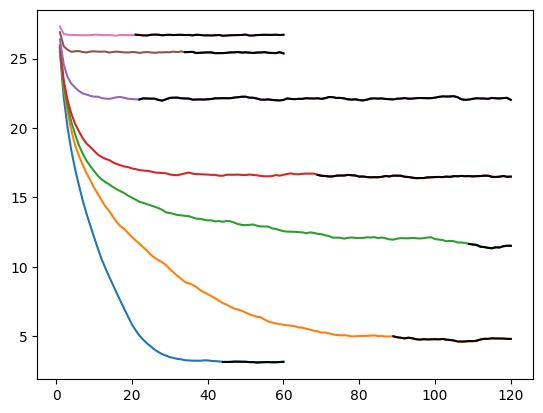

In [ ]:
#T = 0.4
f = [0, 0.5, 0.75, 1, 2, 3.5, 5]
t = 0.4
Rgfolder = '../Data/Block1/Radius of gyration/ForcesT04'
Reefolder = '../Data/Block1/End-to-end distance/ForcesT04'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT04 = CGT(f, t, 1, Reepaths, Rgpaths)

Slope is -0.014913249999999987 pm 0.003983052904598859 with p value 0.16615115695329635
Slope is -0.004226328571428499 pm 0.0027603712579127126 with p value 0.1766308127187974
Slope is 0.00616194972191323 pm 0.003079214943315908 with p value 0.055154977222195006
Slope is 0.002861999439775905 pm 0.0015210615225097355 with p value 0.06873891440421633
Slope is 0.0007164744840525565 pm 0.00039531344974659516 with p value 0.07782798770535826


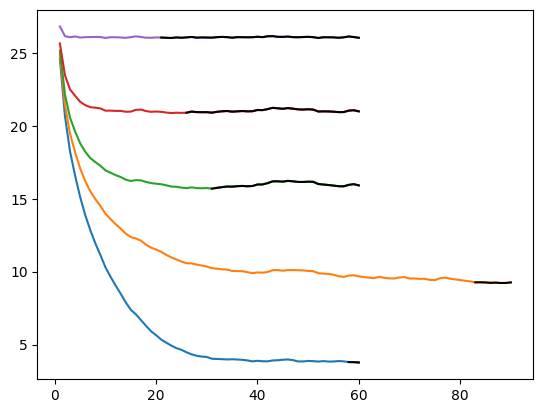

In [ ]:
#T = 0.5
f = [0, 0.5, 1, 2, 5]
t = 0.5
Rgfolder = '../Data/Block1/Radius of gyration/ForcesT05'
Reefolder = '../Data/Block1/End-to-end distance/ForcesT05'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT05 = CGT(f, t, 1, Reepaths, Rgpaths)

Slope is 0.0019495592120075235 pm 0.0017459262125126963 with p value 0.27116219288787596
Slope is -0.000611091934213975 pm 0.0010374807483017397 with p value 0.5578028035526434
Slope is 0.005422686164736184 pm 0.002682803485905332 with p value 0.05118045519565256
Slope is 0.0025326154575628177 pm 0.0015540484866726613 with p value 0.11213584512683952
Slope is 0.0013876374493926994 pm 0.000713067966401425 with p value 0.059278761645211495


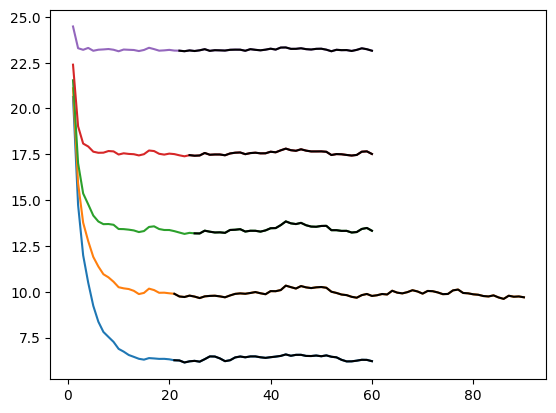

In [ ]:
#T = 1
f = [0, 0.5, 1, 2, 5]
t = 1
Rgfolder = '../Data/Block1/Radius of gyration/ForcesT1'
Reefolder = '../Data/Block1/End-to-end distance/ForcesT1'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT1 = CGT(f, t, 1, Reepaths, Rgpaths)

Slope is 0.0024621015196998066 pm 0.0014021254096325177 with p value 0.08715014244553665
Slope is 0.004291158321114344 pm 0.0024366923820550554 with p value 0.08841969431513651
Slope is 0.0037439739212897457 pm 0.0022350498052179234 with p value 0.10282445410901
Slope is 0.002558418207681326 pm 0.0016009012742004003 with p value 0.11900840538183555
Slope is 0.001009445966228875 pm 0.000815381150666813 with p value 0.22330866274904743


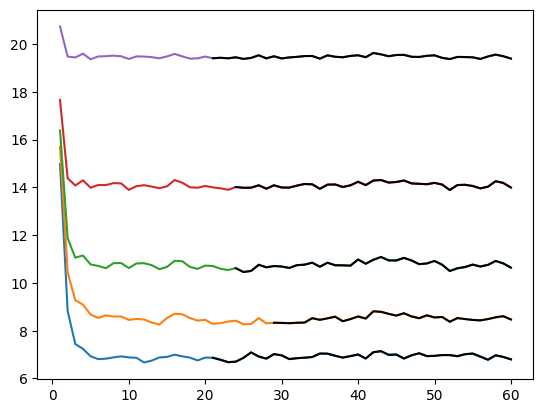

In [ ]:
#T = 2
f = [0, 0.5, 1, 2, 5]
t = 2
Rgfolder = '../Data/Block1/Radius of gyration/ForcesT2'
Reefolder = '../Data/Block1/End-to-end distance/ForcesT2'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT2 = CGT(f, t, 1, Reepaths, Rgpaths)

Slope is -0.000590475656660414 pm 0.001113800970299351 with p value 0.5990960136139181
Slope is 0.0005135092495309611 pm 0.0014086557212189862 with p value 0.7174767874867927
Slope is 0.0006160350375234457 pm 0.0011312659820054722 with p value 0.5892421332876361
Slope is 0.0007947370825515873 pm 0.0013265099207924295 with p value 0.5526489813417208
Slope is 0.0012174773921200968 pm 0.000777271481908084 with p value 0.1255579294644734


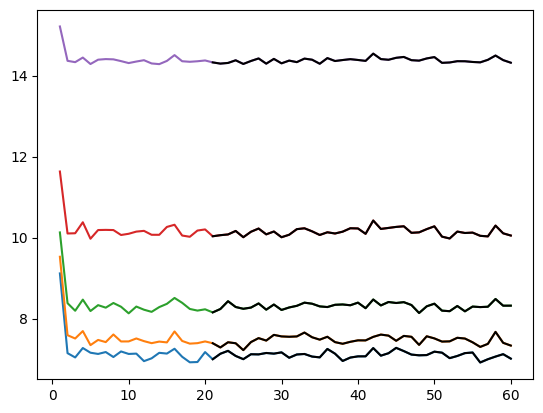

In [ ]:
#T = 5
f = [0, 0.5, 1, 2, 5]
t = 5
Rgfolder = '../Data/Block1/Radius of gyration/ForcesT5'
Reefolder = '../Data/Block1/End-to-end distance/ForcesT5'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT5 = CGT(f, t, 1, Reepaths, Rgpaths)

In [ ]:
with open('Block1_CGT.pkl', 'wb') as file:
    pickle.dump(CGT01, file)
    pickle.dump(CGT03, file)
    pickle.dump(CGT04, file)
    pickle.dump(CGT05, file)
    pickle.dump(CGT1, file)
    pickle.dump(CGT2, file)
    pickle.dump(CGT5, file)

## Block 5

No equilirbium found: F0.3


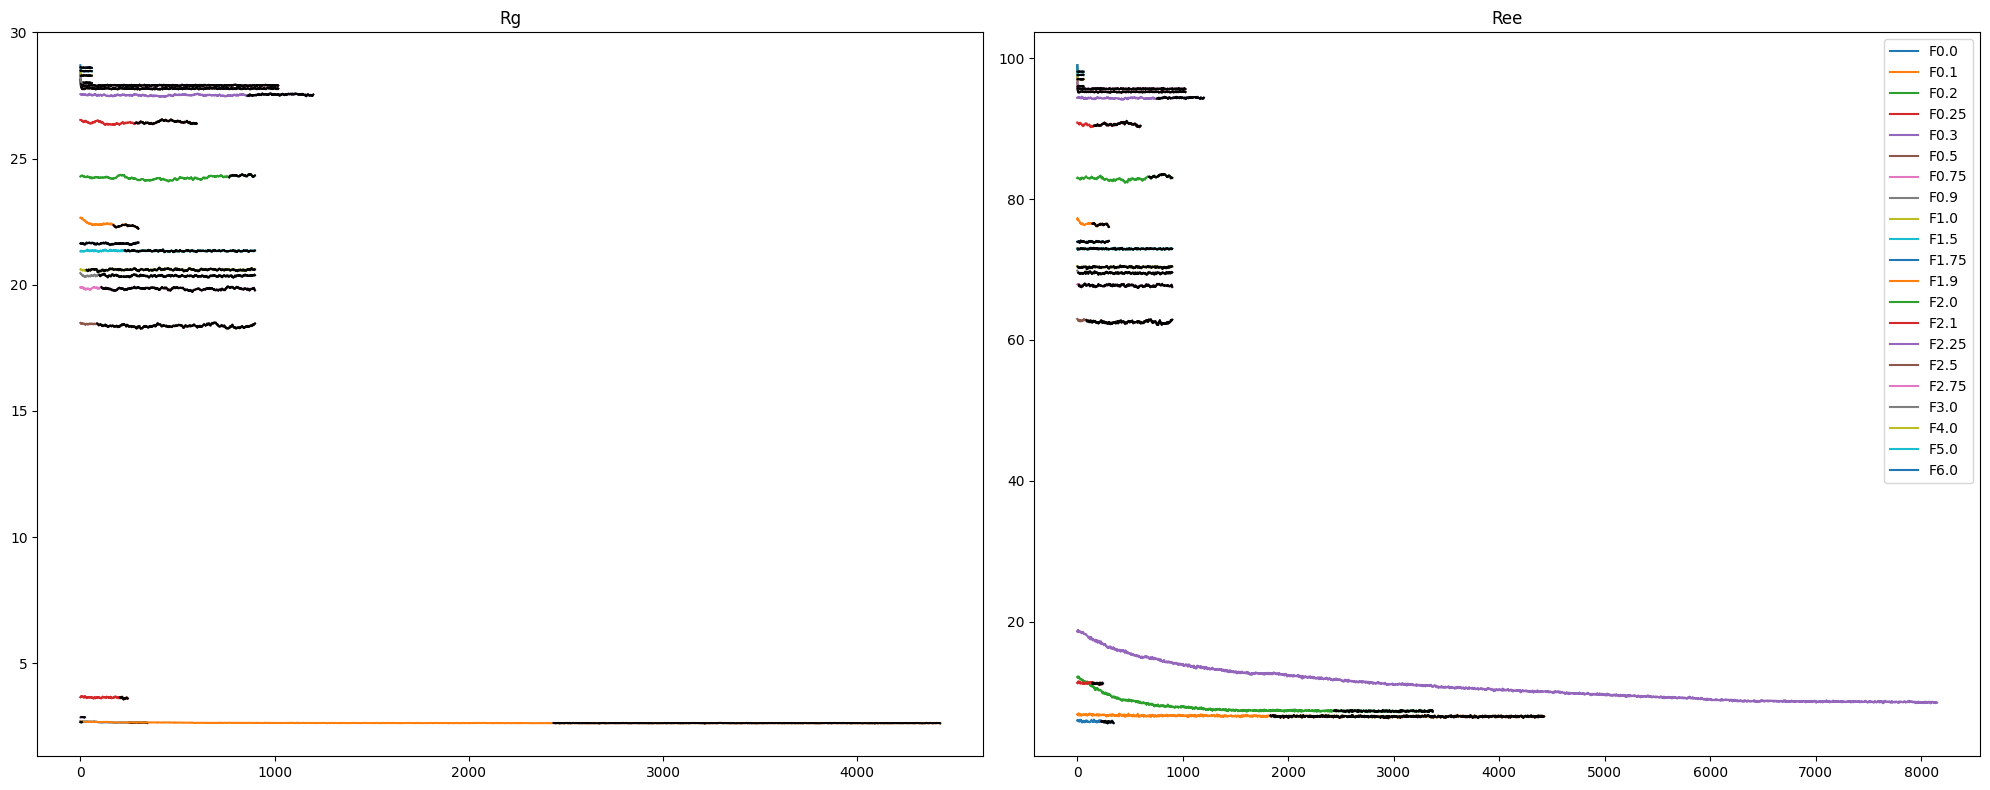

In [36]:
#T = 0.1
f = [0, 0.1, 0.2, 0.25, 0.3, 0.5, 0.75, 0.9, 1, 1.5, 1.75, 1.9, 2, 2.1, 2.25, 2.5, 2.75, 3, 4, 5, 6]
t = 0.1

Reepaths=[
    '../block5/T0.1/force0/p9/dump',
    '../block5/T0.1/force0.1/p5/dump',
    '../block5/T0.1/force0.2/p7/dump.rc2.5N100Tp1',
    '../block5/T0.1/force0.25/p6/dump.rc2.5N100Tp1',
    '../block5/T0.1/force0.3/p9/dump.rc2.5N100Tp1',
    '../block5/T0.1/force0.5/dumpF0.5',
    '../block5/T0.1/force0.75/dumpF0.75',
    '../block5/T0.1/force0.9/p2/dump.rc2.5N100Tp1',
    '../block5/T0.1/force1/p3/dump.rc2.5N100Tp1',
    '../block5/T0.1/force1.5/p3/dump.rc2.5N100Tp1',
    '../block5/T0.1/force1.75/p2/dump.rc2.5N100Tp1',
    '../block5/T0.1/force1.9/p2/dump.rc2.5N100Tp1',
    '../block5/T0.1/force2/p5/dump.rc2.5N100Tp1',
    '../block5/T0.1/force2.1/dumpF2.1',
    '../block5/T0.1/force2.25/dumpF2.25',
    '../block5/T0.1/force2.5/dumpF2.5',
    '../block5/T0.1/force2.75/dumpF2.75',
    '../block5/T0.1/force3/dump.rc2.5N100Tp1',
    '../block5/T0.1/force4/dump.rc2.5N100Tp1',
    '../block5/T0.1/force5/dump.rc2.5N100Tp1',
    '../block5/T0.1/force6/dump'
]

Rgpaths = [
    '../block5/T0.1/force0/p9/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force0.1/p5/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force0.2/p7/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force0.25/p6/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force0.3/p9/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force0.5/RgF0.5',
    '../block5/T0.1/force0.75/RgF0.75',
    '../block5/T0.1/force0.9/p2/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force1/p3/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force1.5/p3/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force1.75/p2/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force1.9/p2/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force2/p5/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force2.1/RgF2.1',
    '../block5/T0.1/force2.25/RgF2.25',
    '../block5/T0.1/force2.5/RgF2.5',
    '../block5/T0.1/force2.75/RgF2.75',
    '../block5/T0.1/force3/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force4/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force5/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force6/sv.rc2.5N100T0.1p1'
]

CGT01 = CGT(f, t, 5, Reepaths, Rgpaths)

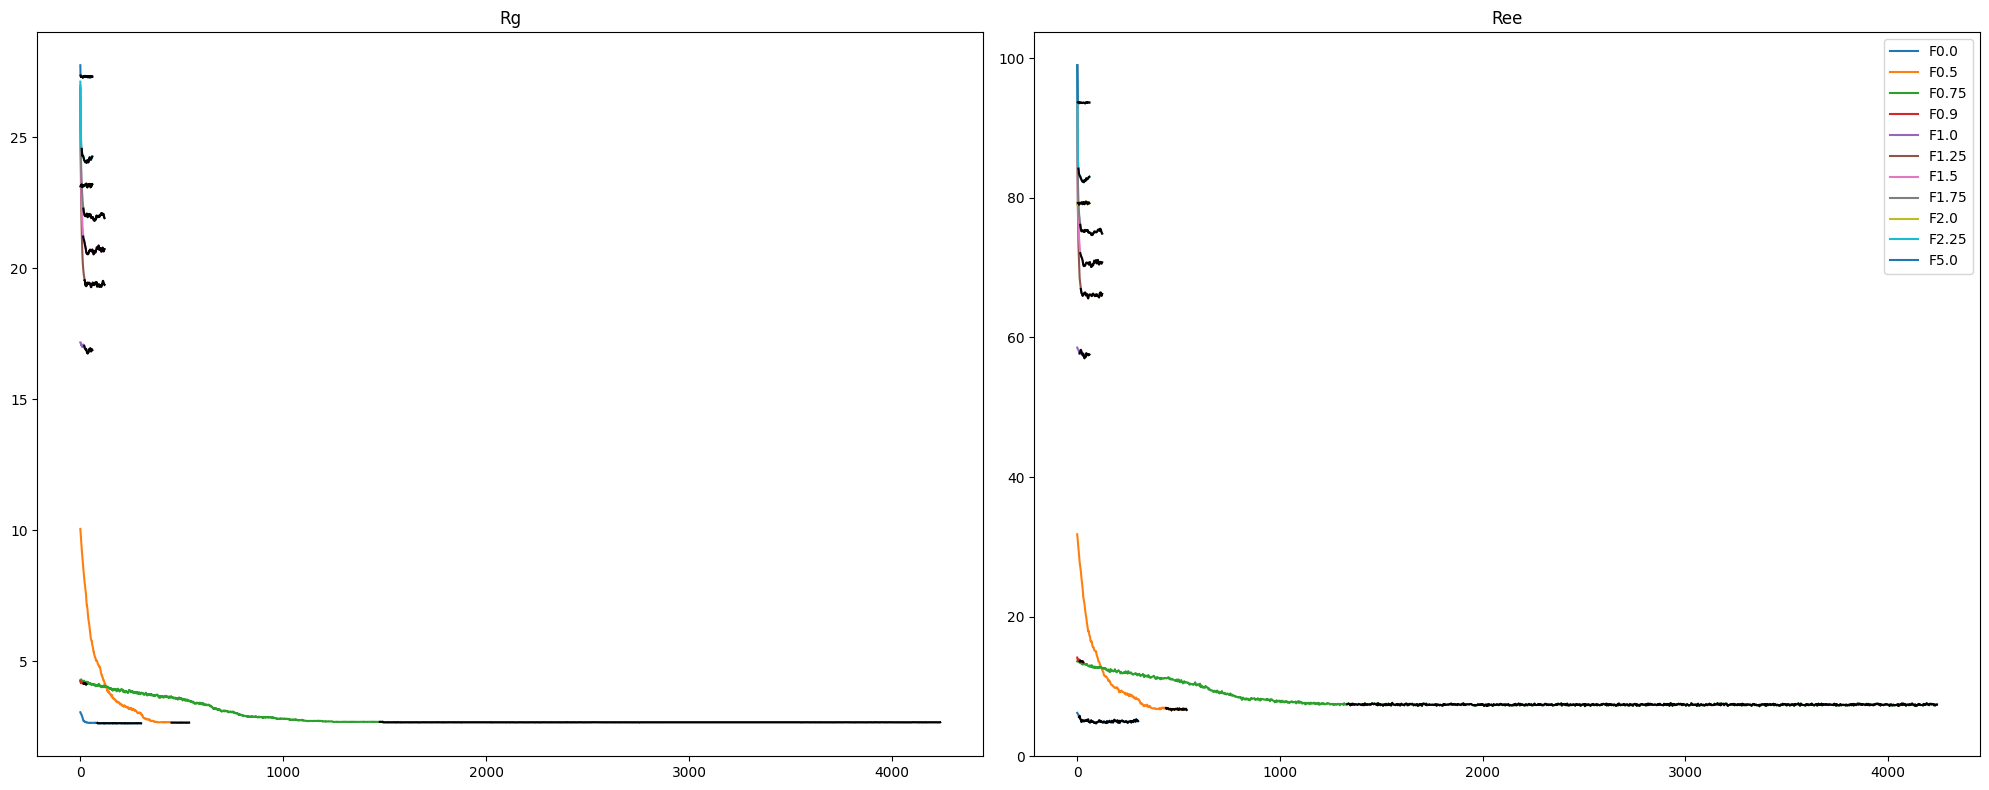

In [23]:
#T = 0.3
f = [0, 0.5, 0.75, 0.9, 1, 1.25, 1.5, 1.75, 2, 2.25, 5]
t = 0.3
Rgpaths = [
    '../block5/T0.3/force0/p2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force0.5/p2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force0.75/p4/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force0.9/p2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force1/p3/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force1.25/RgF1.25',
    '../block5/T0.3/force1.5/RgF1.5',
    '../block5/T0.3/force1.75/RgF1.75',
    '../block5/T0.3/force2/p2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force2.25/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force5/sv.rc2.5N100T0.3p1'
]
Reepaths = [
    '../block5/T0.3/force0/p2/dump.rc2.5N100Tp1',
    '../block5/T0.3/force0.5/p2/dump.rc2.5N100Tp1',
    '../block5/T0.3/force0.75/p4/dump.rc2.5N100Tp1',
    '../block5/T0.3/force0.9/p2/dump.rc2.5N100Tp1',
    '../block5/T0.3/force1/p3/dump.rc2.5N100Tp1',
    '../block5/T0.3/force1.25/dumpF1.25',
    '../block5/T0.3/force1.5/dumpF1.5',
    '../block5/T0.3/force1.75/dumpF1.75',
    '../block5/T0.3/force2/p2/dump.rc2.5N100Tp1',
    '../block5/T0.3/force2.25/dump.rc2.5N100Tp1',
    '../block5/T0.3/force5/dump.rc2.5N100Tp1'
]

CGT03 = CGT(f, t, 5, Reepaths, Rgpaths)

No equilirbium found: F0.6
No equilirbium found: F0.75
No equilirbium found: F1.0
No equilirbium found: F1.0
No equilirbium found: F1.075


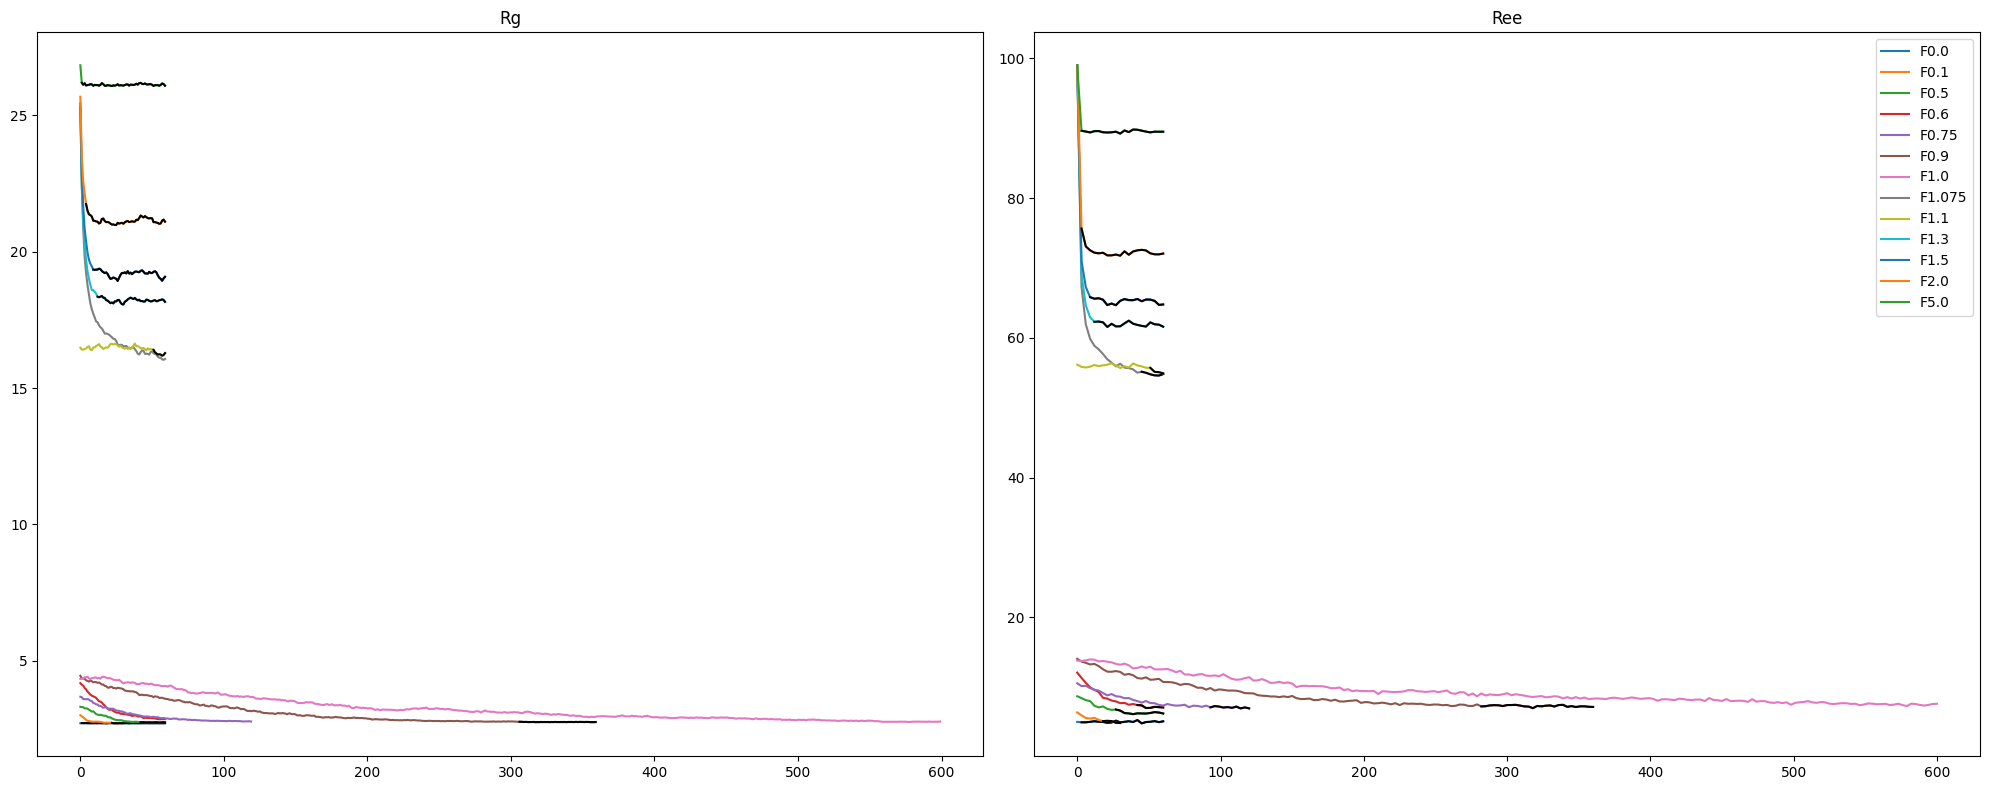

In [19]:
#T = 0.5
f = [0, 0.1, 0.5, 0.6, 0.75, 0.9, 1, 1.075, 1.1, 1.3, 1.5, 2, 5]
t = 0.5

Rgpaths = [
    '../block5/T0.5/force0/p2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force0.1/p2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force0.5/p2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force0.6/p2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force0.75/p3/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force0.9/p4/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force1/p5/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force1.075/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force1.1/p2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force1.3/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force1.5/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force5/sv.rc2.5N100T0.5p1'
    
]
Reepaths = [
    '../block5/T0.5/force0/p2/dump',
    '../block5/T0.5/force0.1/p2/dump.rc2.5N100Tp1',
    '../block5/T0.5/force0.5/p2/dump.rc2.5N100Tp1',
    '../block5/T0.5/force0.6/p2/dump.rc2.5N100Tp1',
    '../block5/T0.5/force0.75/p3/dump.rc2.5N100Tp1',
    '../block5/T0.5/force0.9/p4/dump.rc2.5N100Tp1',
    '../block5/T0.5/force1/p5/dump.rc2.5N100Tp1',
    '../block5/T0.5/force1.075/dump.rc2.5N100Tp1',
    '../block5/T0.5/force1.1/p2/dump.rc2.5N100Tp1',
    '../block5/T0.5/force1.3/dump.rc2.5N100Tp1',
    '../block5/T0.5/force1.5/dump.rc2.5N100Tp1',
    '../block5/T0.5/force2/dump.rc2.5N100Tp1',
    '../block5/T0.5/force5/dump.rc2.5N100Tp1'
]

CGT05 = CGT(f, t, 5, Reepaths, Rgpaths)

No equilirbium found: F0.8


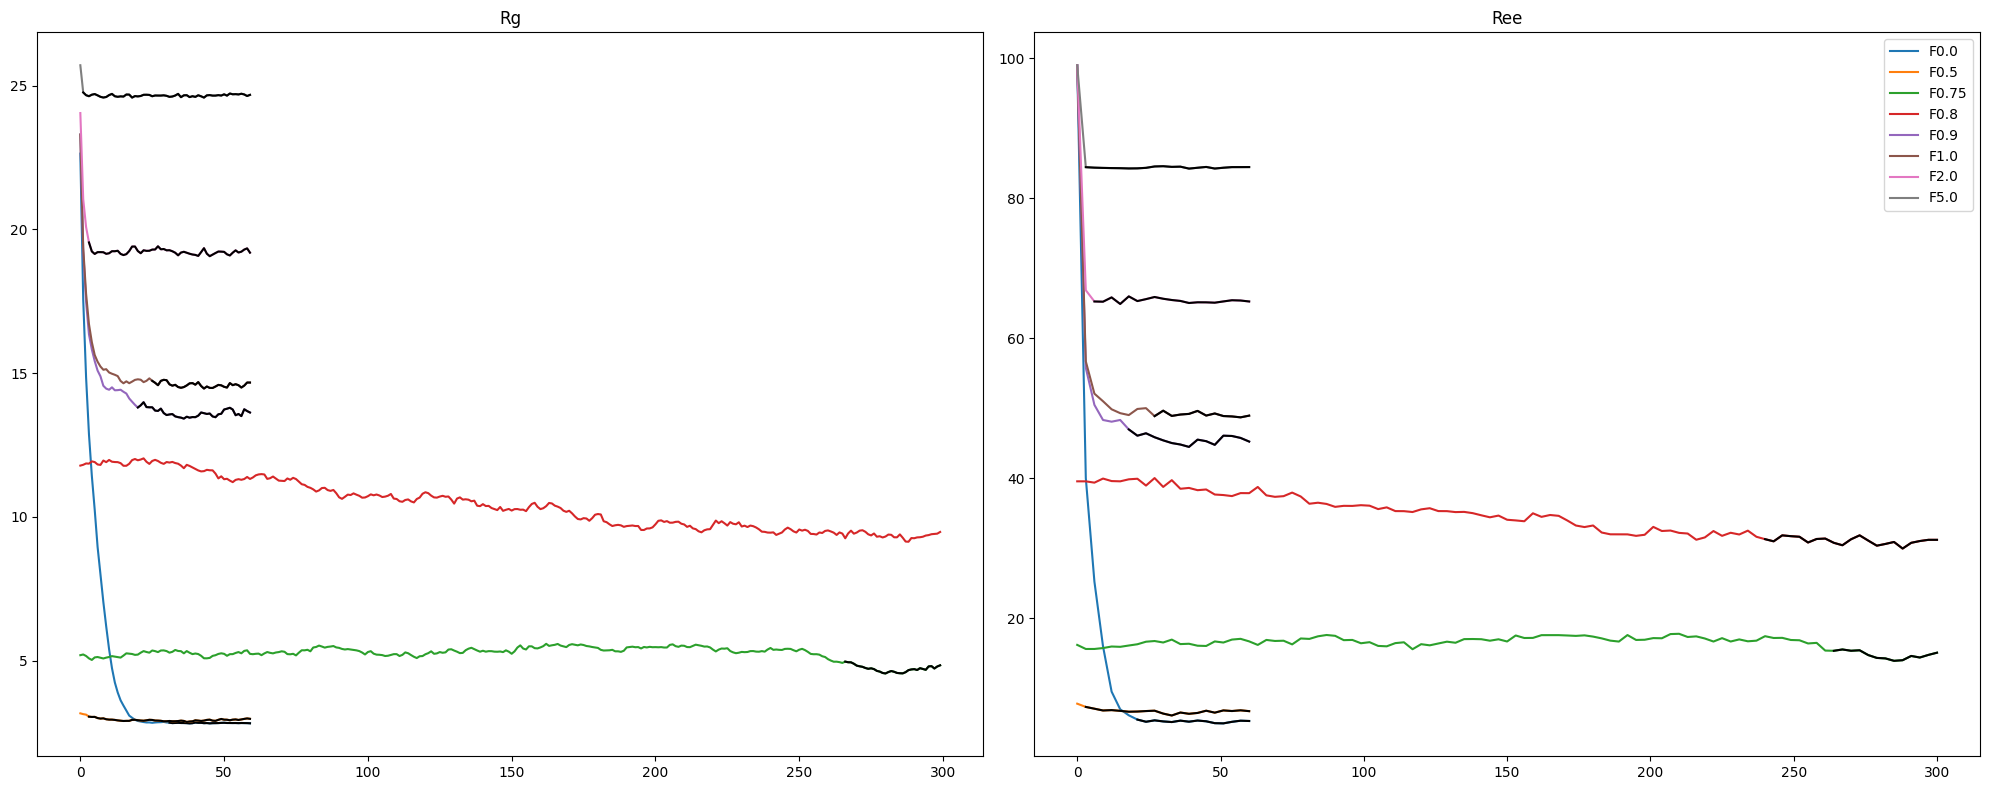

In [41]:
#T = 0.75
f = [0, 0.5, 0.75, 0.8, 0.9, 1, 2, 5]
t = 0.75

Rgpaths = [
    '../block5/T0.75/force0/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force0.5/p2/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force0.75/p4/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force0.8/p2/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force0.9/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force1/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force2/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force5/sv.rc2.5N100T0.75p1'
]
Reepaths = [
    '../block5/T0.75/force0/dump.rc2.5N100Tp1',
    '../block5/T0.75/force0.5/p2/dump.rc2.5N100Tp1',
    '../block5/T0.75/force0.75/p4/dump.rc2.5N100Tp1',
    '../block5/T0.75/force0.8/p2/dump.rc2.5N100Tp1',
    '../block5/T0.75/force0.9/dump.rc2.5N100Tp1',
    '../block5/T0.75/force1/dump.rc2.5N100Tp1',
    '../block5/T0.75/force2/dump.rc2.5N100Tp1',
    '../block5/T0.75/force5/dump.rc2.5N100Tp1'
]

CGT075 = CGT(f, t, 5, Reepaths, Rgpaths)

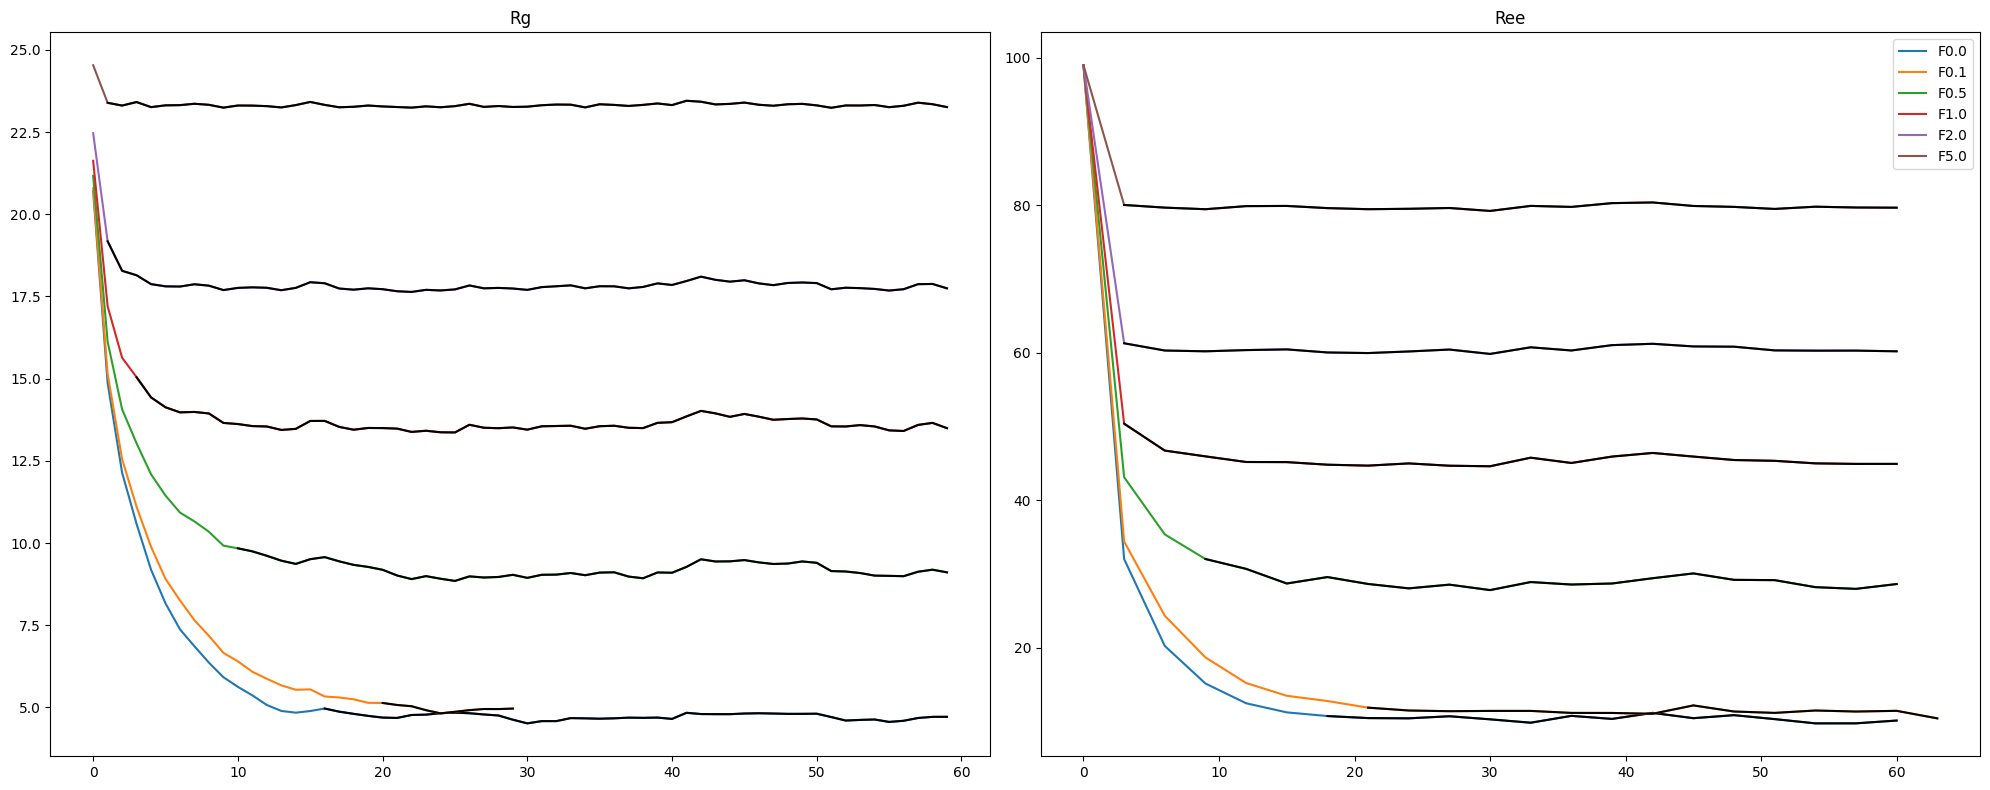

In [42]:
#T = 1
f = [0, 0.1, 0.5, 1, 2, 5]
t = 1

Rgpaths = [
    '../block5/T1/force0/sv.rc2.5N100T1p1',
    '../block5/T1/force0.1/sv.rc2.5N100T1p1',
    '../block5/T1/force0.5/sv.rc2.5N100T1p1',
    '../block5/T1/force1/sv.rc2.5N100T1p1',
    '../block5/T1/force2/sv.rc2.5N100T1p1',
    '../block5/T1/force5/sv.rc2.5N100T1p1'
]
Reepaths = [
    '../block5/T1/force0/dump.rc2.5N100Tp1',
    '../block5/T1/force0.1/dump.rc2.5N100Tp1',
    '../block5/T1/force0.5/dump.rc2.5N100Tp1',
    '../block5/T1/force1/dump.rc2.5N100Tp1',
    '../block5/T1/force2/dump.rc2.5N100Tp1',
    '../block5/T1/force5/dump.rc2.5N100Tp1',
]

CGT1 = CGT(f, t, 5, Reepaths, Rgpaths)

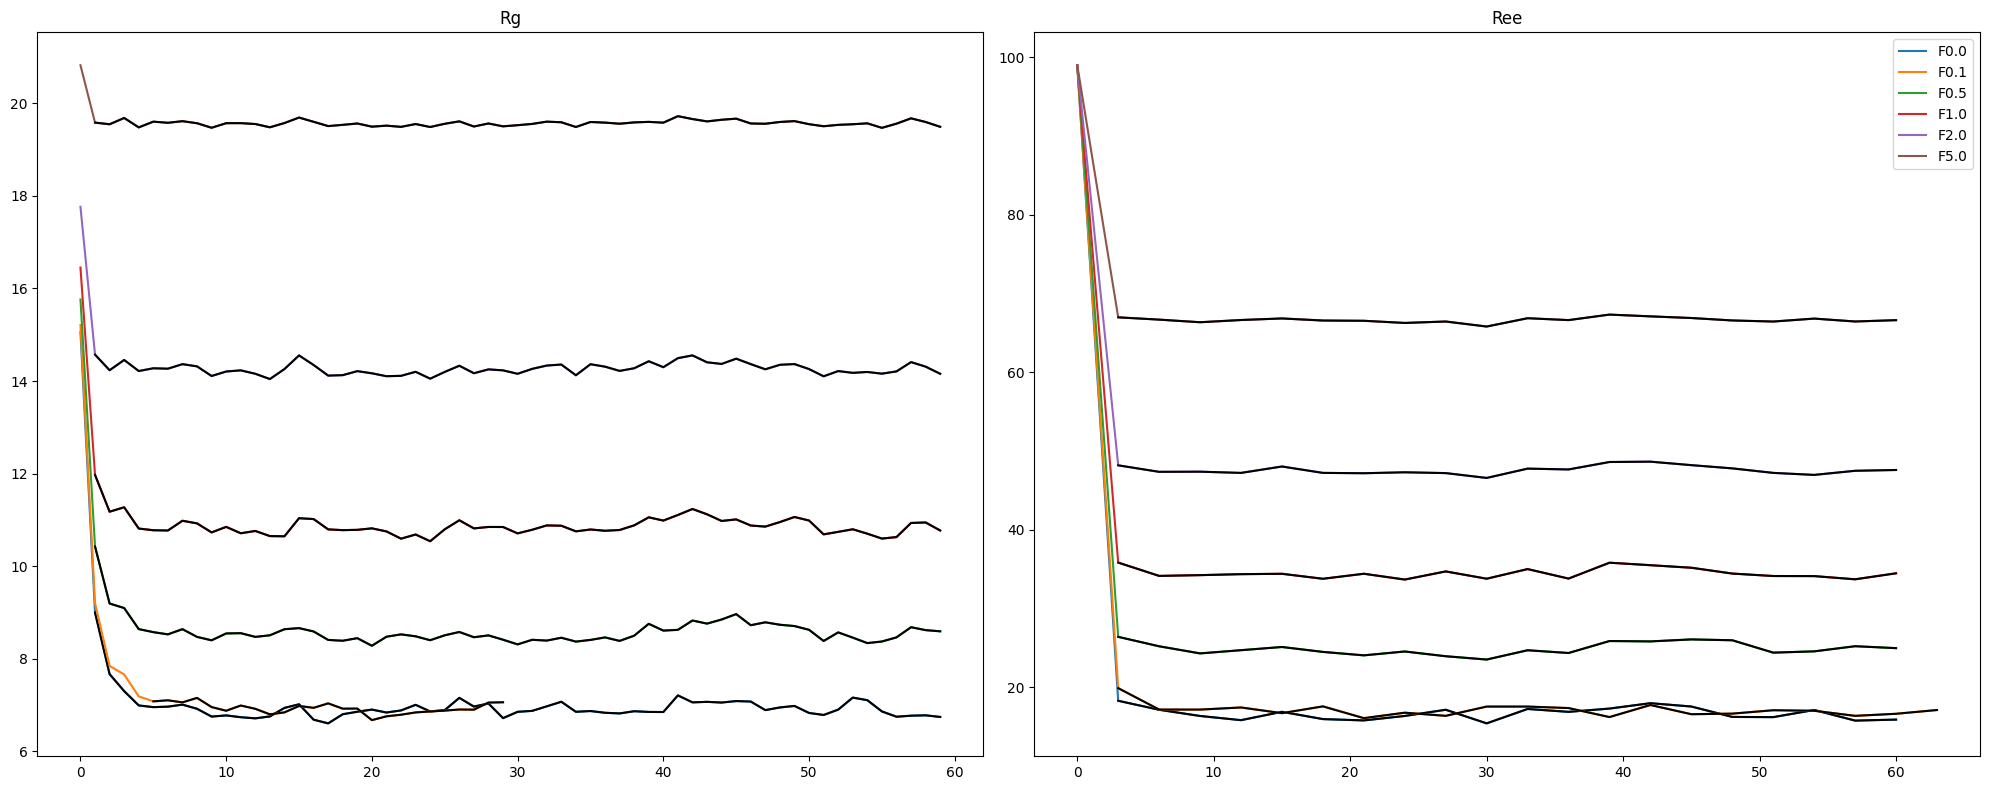

In [43]:
#T = 2
f = [0, 0.1, 0.5, 1, 2, 5]
t = 2

Rgpaths = [
    '../block5/T2/force0/sv.rc2.5N100T2p1',
    '../block5/T2/force0.1/sv.rc2.5N100T2p1',
    '../block5/T2/force0.5/sv.rc2.5N100T2p1',
    '../block5/T2/force1/sv.rc2.5N100T2p1',
    '../block5/T2/force2/sv.rc2.5N100T2p1',
    '../block5/T2/force5/sv.rc2.5N100T2p1',
]
Reepaths = [
    '../block5/T2/force0/dump.rc2.5N100Tp1',
    '../block5/T2/force0.1/dump.rc2.5N100Tp1',
    '../block5/T2/force0.5/dump.rc2.5N100Tp1',
    '../block5/T2/force1/dump.rc2.5N100Tp1',
    '../block5/T2/force2/dump.rc2.5N100Tp1',
    '../block5/T2/force5/dump.rc2.5N100Tp1',
]

CGT2 = CGT(f, t, 5, Reepaths, Rgpaths)

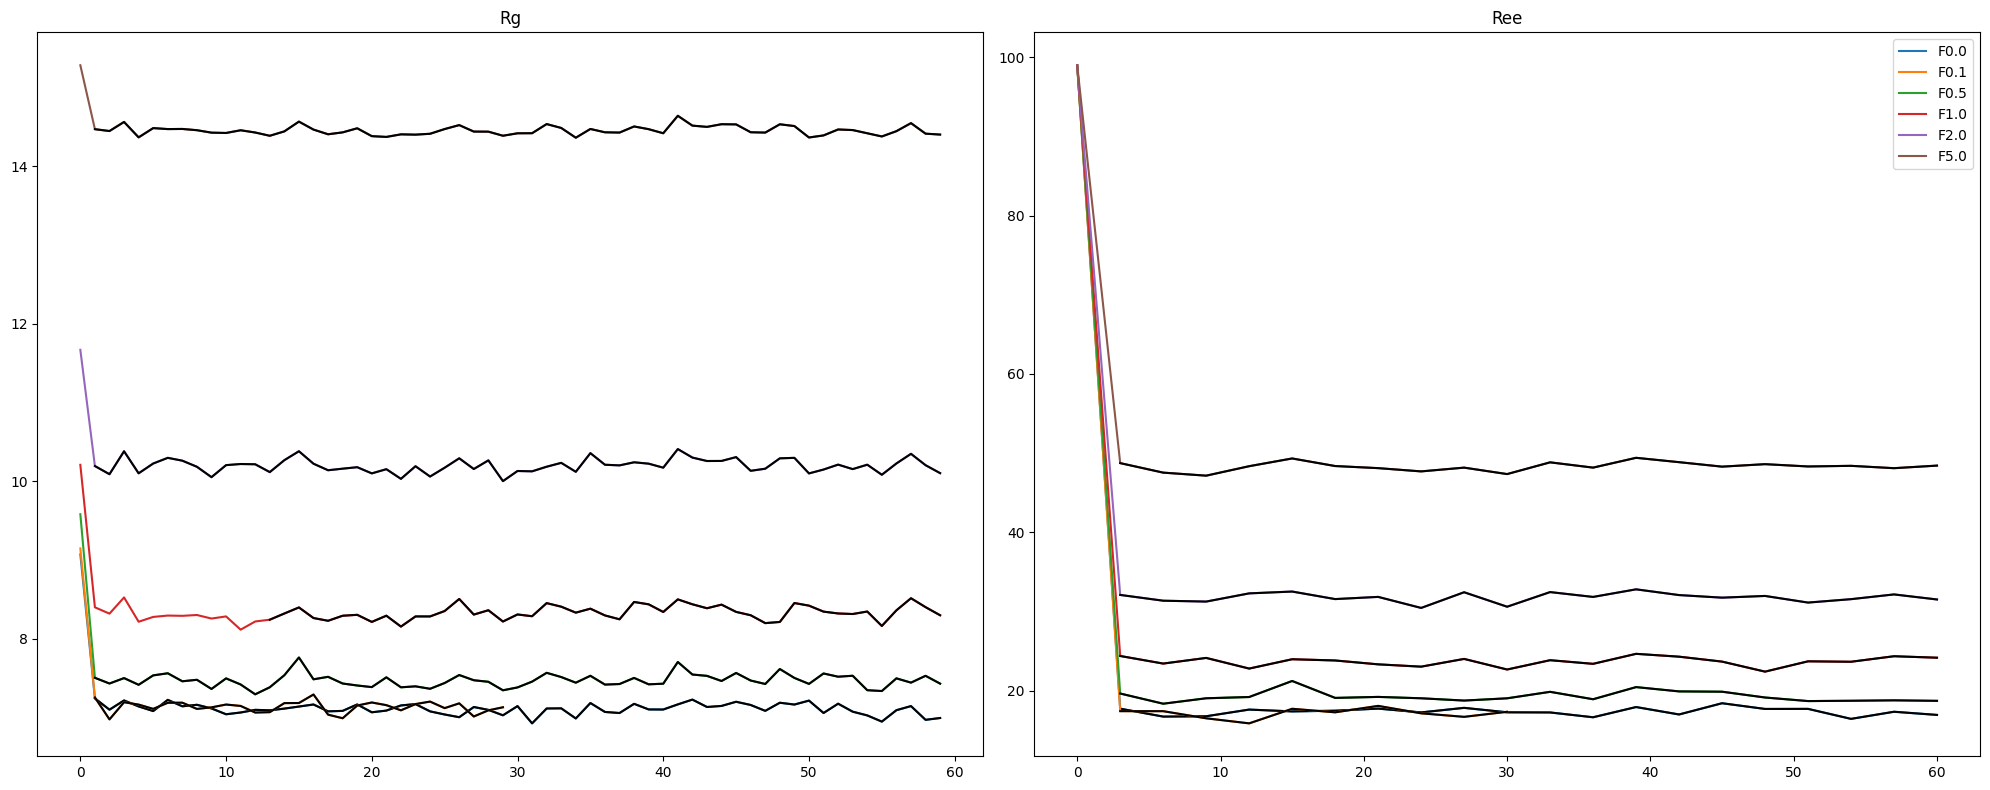

In [44]:
#T = 5
f = [0, 0.1, 0.5, 1, 2, 5]
t = 5

Rgpaths = [
    '../block5/T5/force0/sv.rc2.5N100T5p1',
    '../block5/T5/force0.1/sv.rc2.5N100T5p1',
    '../block5/T5/force0.5/sv.rc2.5N100T5p1',
    '../block5/T5/force1/sv.rc2.5N100T5p1',
    '../block5/T5/force2/sv.rc2.5N100T5p1',
    '../block5/T5/force5/sv.rc2.5N100T5p1',
]

Reepaths = [
    '../block5/T5/force0/dump.rc2.5N100Tp1',
    '../block5/T5/force0.1/dump.rc2.5N100Tp1',
    '../block5/T5/force0.5/dump.rc2.5N100Tp1',
    '../block5/T5/force1/dump.rc2.5N100Tp1',
    '../block5/T5/force2/dump.rc2.5N100Tp1',
    '../block5/T5/force5/dump.rc2.5N100Tp1',
]

CGT5 = CGT(f, t, 5, Reepaths, Rgpaths)

In [ ]:
with open('Block5_CGT.pkl', 'wb') as file:
    pickle.dump(CGT01, file)
    pickle.dump(CGT03, file)
    pickle.dump(CGT05, file)
    pickle.dump(CGT075, file)
    pickle.dump(CGT1, file)
    pickle.dump(CGT2, file)
    pickle.dump(CGT5, file)

## Block 10

No equilirbium found: F2.5


ValueError: cannot reshape array of size 337320000 into shape (3747,10000,9)

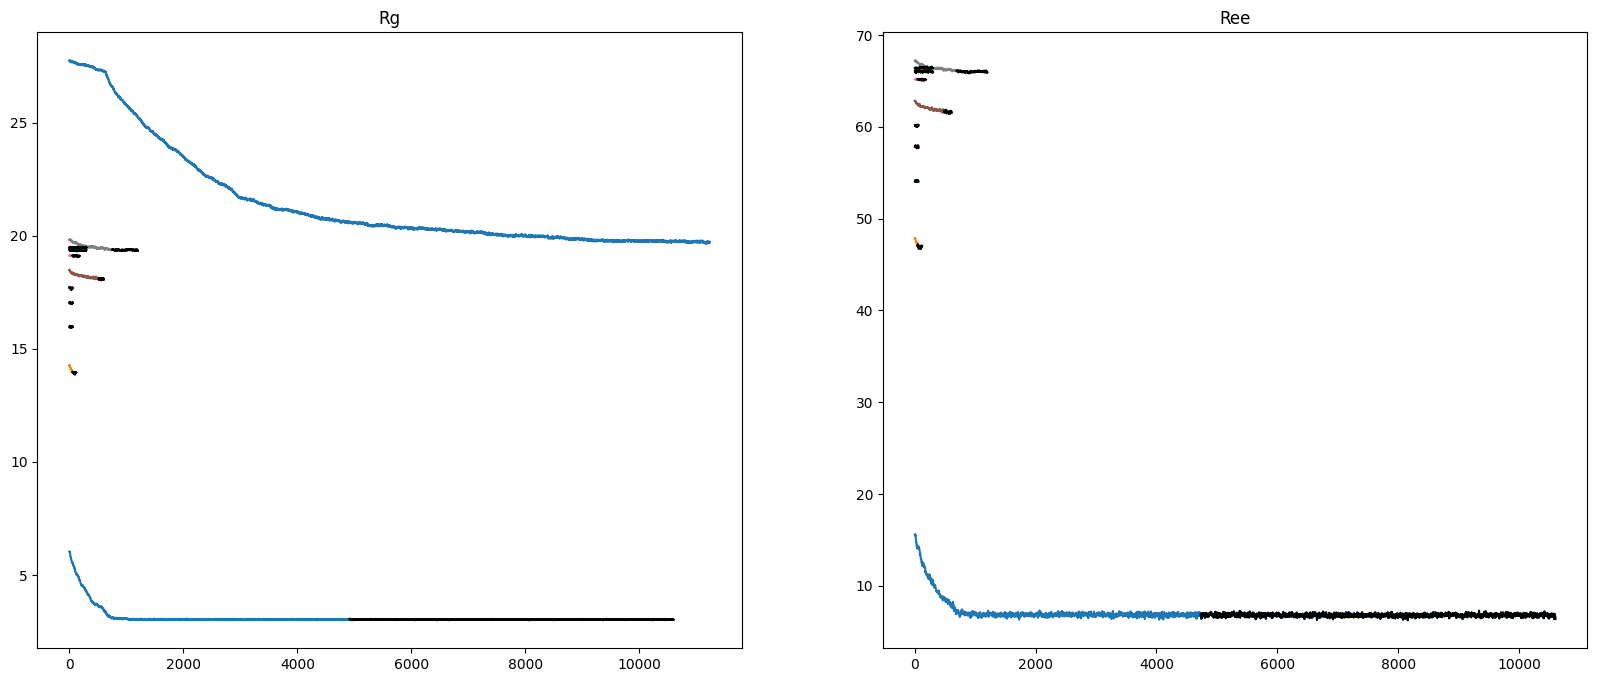

In [40]:
#T = 0.1
f = [0, 0.25, 0.5, 0.75, 1, 1.25, 2, 2.25, 2.3, 2.4, 2.5, 3, 5]
t = 0.1

Rgpaths = [
    '../block10/T0.1/force0/p3/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force0.25/p2/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force0.5/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force0.75/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force1/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force1.25/p4/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force2/RgF2',
    '../block10/T0.1/force2.25/p3/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force2.3/p4/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force2.4/p4/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force2.5/p2/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force3/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force5/sv.rc2.5N100T0.1p1',
]
Reepaths = [
    '../block10/T0.1/force0/p3/dump.rc2.5N100Tp1',
    '../block10/T0.1/force0.25/p2/dump.rc2.5N100Tp1',
    '../block10/T0.1/force0.5/dump.rc2.5N100Tp1',
    '../block10/T0.1/force0.75/dump.rc2.5N100Tp1',
    '../block10/T0.1/force1/dump.rc2.5N100Tp1',
    '../block10/T0.1/force1.25/p4/dump',
    '../block10/T0.1/force2/dumpF2',
    '../block10/T0.1/force2.25/p3/dump',
    '../block10/T0.1/force2.3/p4/dump',
    '../block10/T0.1/force2.4/p4/dump',
    '../block10/T0.1/force2.5/p2/dump',
    '../block10/T0.1/force3/dump.rc2.5N100Tp1',
    '../block10/T0.1/force5/dump.rc2.5N100Tp1',
]

CGT01 = CGT(f, t, 10, Reepaths, Rgpaths)

No equilirbium found: F0.5
No equilirbium found: F0.5


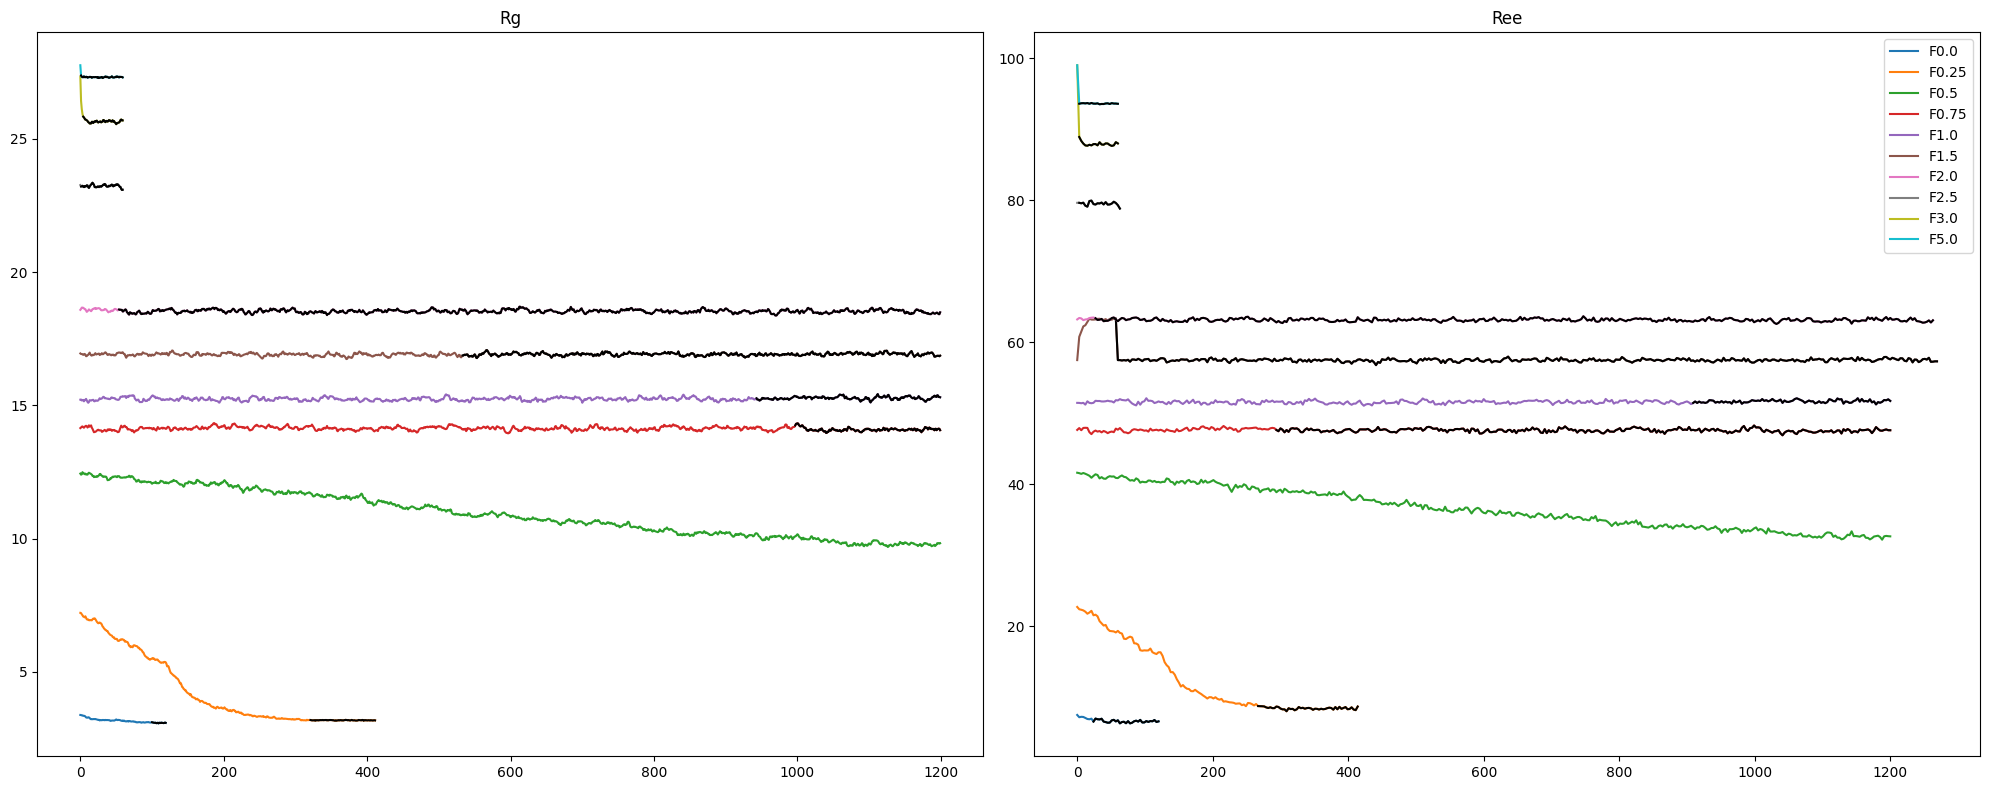

In [33]:
#T = 0.3
f = [0, 0.25, 0.5, 0.75, 1, 1.5, 2, 2.5, 3, 5]
t = 0.3

Rgpaths = [
    '../block10/T0.3/force0/p2/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force0.25/p2/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force0.5/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force0.75/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force1/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force1.5/p2/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force2/p2/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force2.5/p2/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force3/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force5/sv.rc2.5N100T0.3p1',
]
Reepaths = [
    '../block10/T0.3/force0/p2/dump.rc2.5N100Tp1',
    '../block10/T0.3/force0.25/p2/dump.rc2.5N100Tp1',
    '../block10/T0.3/force0.5/dump',
    '../block10/T0.3/force0.75/dump',
    '../block10/T0.3/force1/dump',
    '../block10/T0.3/force1.5/p2/dump',
    '../block10/T0.3/force2/p2/dump',
    '../block10/T0.3/force2.5/p2/dump.rc2.5N100Tp1',
    '../block10/T0.3/force3/dump.rc2.5N100Tp1',
    '../block10/T0.3/force5/dump.rc2.5N100Tp1',
]


CGT03 = CGT(f, t, 10, Reepaths, Rgpaths)

In [ ]:
filename = 'Block10_CGT.pkl'

with open(filename, 'wb') as file:
    pickle.dump(CGT01, file)
    pickle.dump(CGT03, file)

## Block 50

In [ ]:
#T = 0.1
f = [0, 0.5, 1, 2, 2.2, 2.5, 3, 3.5, 5]
t = 0.1
Rgfolder = '../Data/Block50/Radius of gyration/ForcesT01'
Reefolder = '../Data/Block50/End-to-end distance/ForcesT01'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT01 = CGT(f, t, 50, Reepaths, Rgpaths)

In [ ]:
#T = 0.3
f = [0, 0.5, 1, 2, 2.5, 3, 4, 5]
t = 0.3
Rgfolder = '../Data/Block50/Radius of gyration/ForcesT03'
Reefolder = '../Data/Block50/End-to-end distance/ForcesT03'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT03 = CGT(f, t, 50, Reepaths, Rgpaths)

In [ ]:
#T = 0.5
f = [0, 0.5, 1, 2, 2.5, 3, 5, 7, 10]
t = 0.5
Rgfolder = '../Data/Block50/Radius of gyration/ForcesT05'
Reefolder = '../Data/Block50/End-to-end distance/ForcesT05'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT05 = CGT(f, t, 50, Reepaths, Rgpaths)

In [ ]:
#T = 0.75
f = [0, 0.5, 1, 2, 3, 4, 5]
t = 0.75
Rgfolder = '../Data/Block50/Radius of gyration/ForcesT075'
Reefolder = '../Data/Block50/End-to-end distance/ForcesT075'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT075 = CGT(f, t, 50, Reepaths, Rgpaths)

Use temporary mean starting halfway:F = 4.0


In [ ]:
#T = 1
f = [0, 0.5, 1, 2, 2.5, 3.5, 5, 7, 10]
t = 1
Rgfolder = '../Data/Block50/Radius of gyration/ForcesT1'
Reefolder = '../Data/Block50/End-to-end distance/ForcesT1'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT1 = CGT(f, t, 50, Reepaths, Rgpaths)

In [ ]:
#T = 2
f = [0, 0.5, 1, 2, 5, 7, 10]
t = 2
Rgfolder = '../Data/Block50/Radius of gyration/ForcesT2'
Reefolder = '../Data/Block50/End-to-end distance/ForcesT2'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT2 = CGT(f, t, 50, Reepaths, Rgpaths)

Use temporary mean starting halfway:F = 0.5


In [ ]:
#T = 5
f = [0,  0.5, 1, 2, 5, 7, 10]
t = 5
Rgfolder = '../Data/Block50/Radius of gyration/ForcesT5'
Reefolder = '../Data/Block50/End-to-end distance/ForcesT5'
Rgpaths = []
Reepaths = []
for path in os.listdir(Rgfolder):
    Rgpaths.append(Rgfolder + '/' + path)
    Rgpaths.sort()

for path in os.listdir(Reefolder):
    Reepaths.append(Reefolder + '/' + path)
    Reepaths.sort()

CGT5 = CGT(f, t, 50, Reepaths, Rgpaths)

In [ ]:
filename = 'Block50_CGT.pkl'

with open(filename, 'wb') as file:
    pickle.dump(CGT01, file)
    pickle.dump(CGT03, file)
    pickle.dump(CGT05, file)
    pickle.dump(CGT075, file)
    pickle.dump(CGT1, file)
    pickle.dump(CGT2, file)
    pickle.dump(CGT5, file)